# XGBoost Spike Classifier

Multiclass classification model predicting whether each hour is:
- `0` = Normal price
- `1` = Weak spike  (price > mean + 2×std, computed on train set)
- `2` = Strong spike (price > mean + 3×std, computed on train set)

## Key differences from the regressor (xgboost_lasso_v2)
| Topic | Regressor | Classifier |
|---|---|---|
| Target `y` | Raw price (continuous) | Spike class 0/1/2 (integer) |
| Model | XGBRegressor | XGBClassifier |
| Objective | reg:squarederror | multi:softmax |
| Metrics | MAE, RMSE, R² | Precision, Recall, F1, Confusion matrix |
| Class imbalance | n/a | sample_weight balances rare spike classes |
| Lag/rolling features | Built from raw price | Same — raw price is still the input, only `y` changes |

## Cell summary
| Cell | What happens |
|---|---|
| Imports | Libraries incl. XGBClassifier and classification metrics |
| Load data | Read CSV, parse datetime |
| EDA plot | Raw prices, demand, generation, hydro storage Jul–Sep 2024 |
| ffill | Forward-fill gaps |
| Lag non-target cols | 24h lag on prices, energy, demand, flow |
| Shape check | Confirm lag columns exist |
| Time features | Cyclical hour/dow/month encoding |
| Target lags | Lag raw price 24h, 168h, 8760h (input features, not target) |
| Rolling features | Rolling mean/std 24h, 168h, 8760h (leakage-safe) |
| NaN audit | Count warmup NaNs |
| Drop NaNs | Remove first year of rows |
| Define X | Feature matrix (same as regressor) |
| Spike thresholds | Compute mean/std on train portion only — define weak/strong spike labels |
| Class distribution | Show how many hours fall in each class |
| Train/test split | 80/20 time-ordered split |
| Sample weights | Inverse-frequency weights to handle class imbalance |
| Train classifier | XGBClassifier multi:softmax |
| Predict | Class predictions on test set |
| Evaluate | Classification report + confusion matrix |
| Feature importance | Rank features by importance |
| Importance plot | Bar chart + distribution |
| Pruned classifier | Retrain on above-threshold features only |
| Winter forecast plot | 4-month rolling prediction Jul–Oct 2024 vs actual |


In [92]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_sample_weight

In [93]:
# Load data

df = pd.read_csv('../../Data_Processing/preprocessed_data.csv')
df["datetime_utc12"] = pd.to_datetime(df["datetime_utc12"])
df = df.sort_values("datetime_utc12").reset_index(drop=True)

target_col = "el_price_dol_MWh_OTA2201"
print(df.columns.tolist())
print("Shape:", df.shape)

['datetime_utc12', 'el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201', 'Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'wellington_shortwave_wm2', 'wellington_sunshine_s', 'hamilton_shortwave_wm2', 'hamilton_sunshine_s', 'tauranga_shortwave_wm2', 'tauranga_sunshine_s', 'dunedin_shortwave_wm2', 'dunedin_sunshine_s', 'auckland_temp_c', 'christchurch_temp_c'

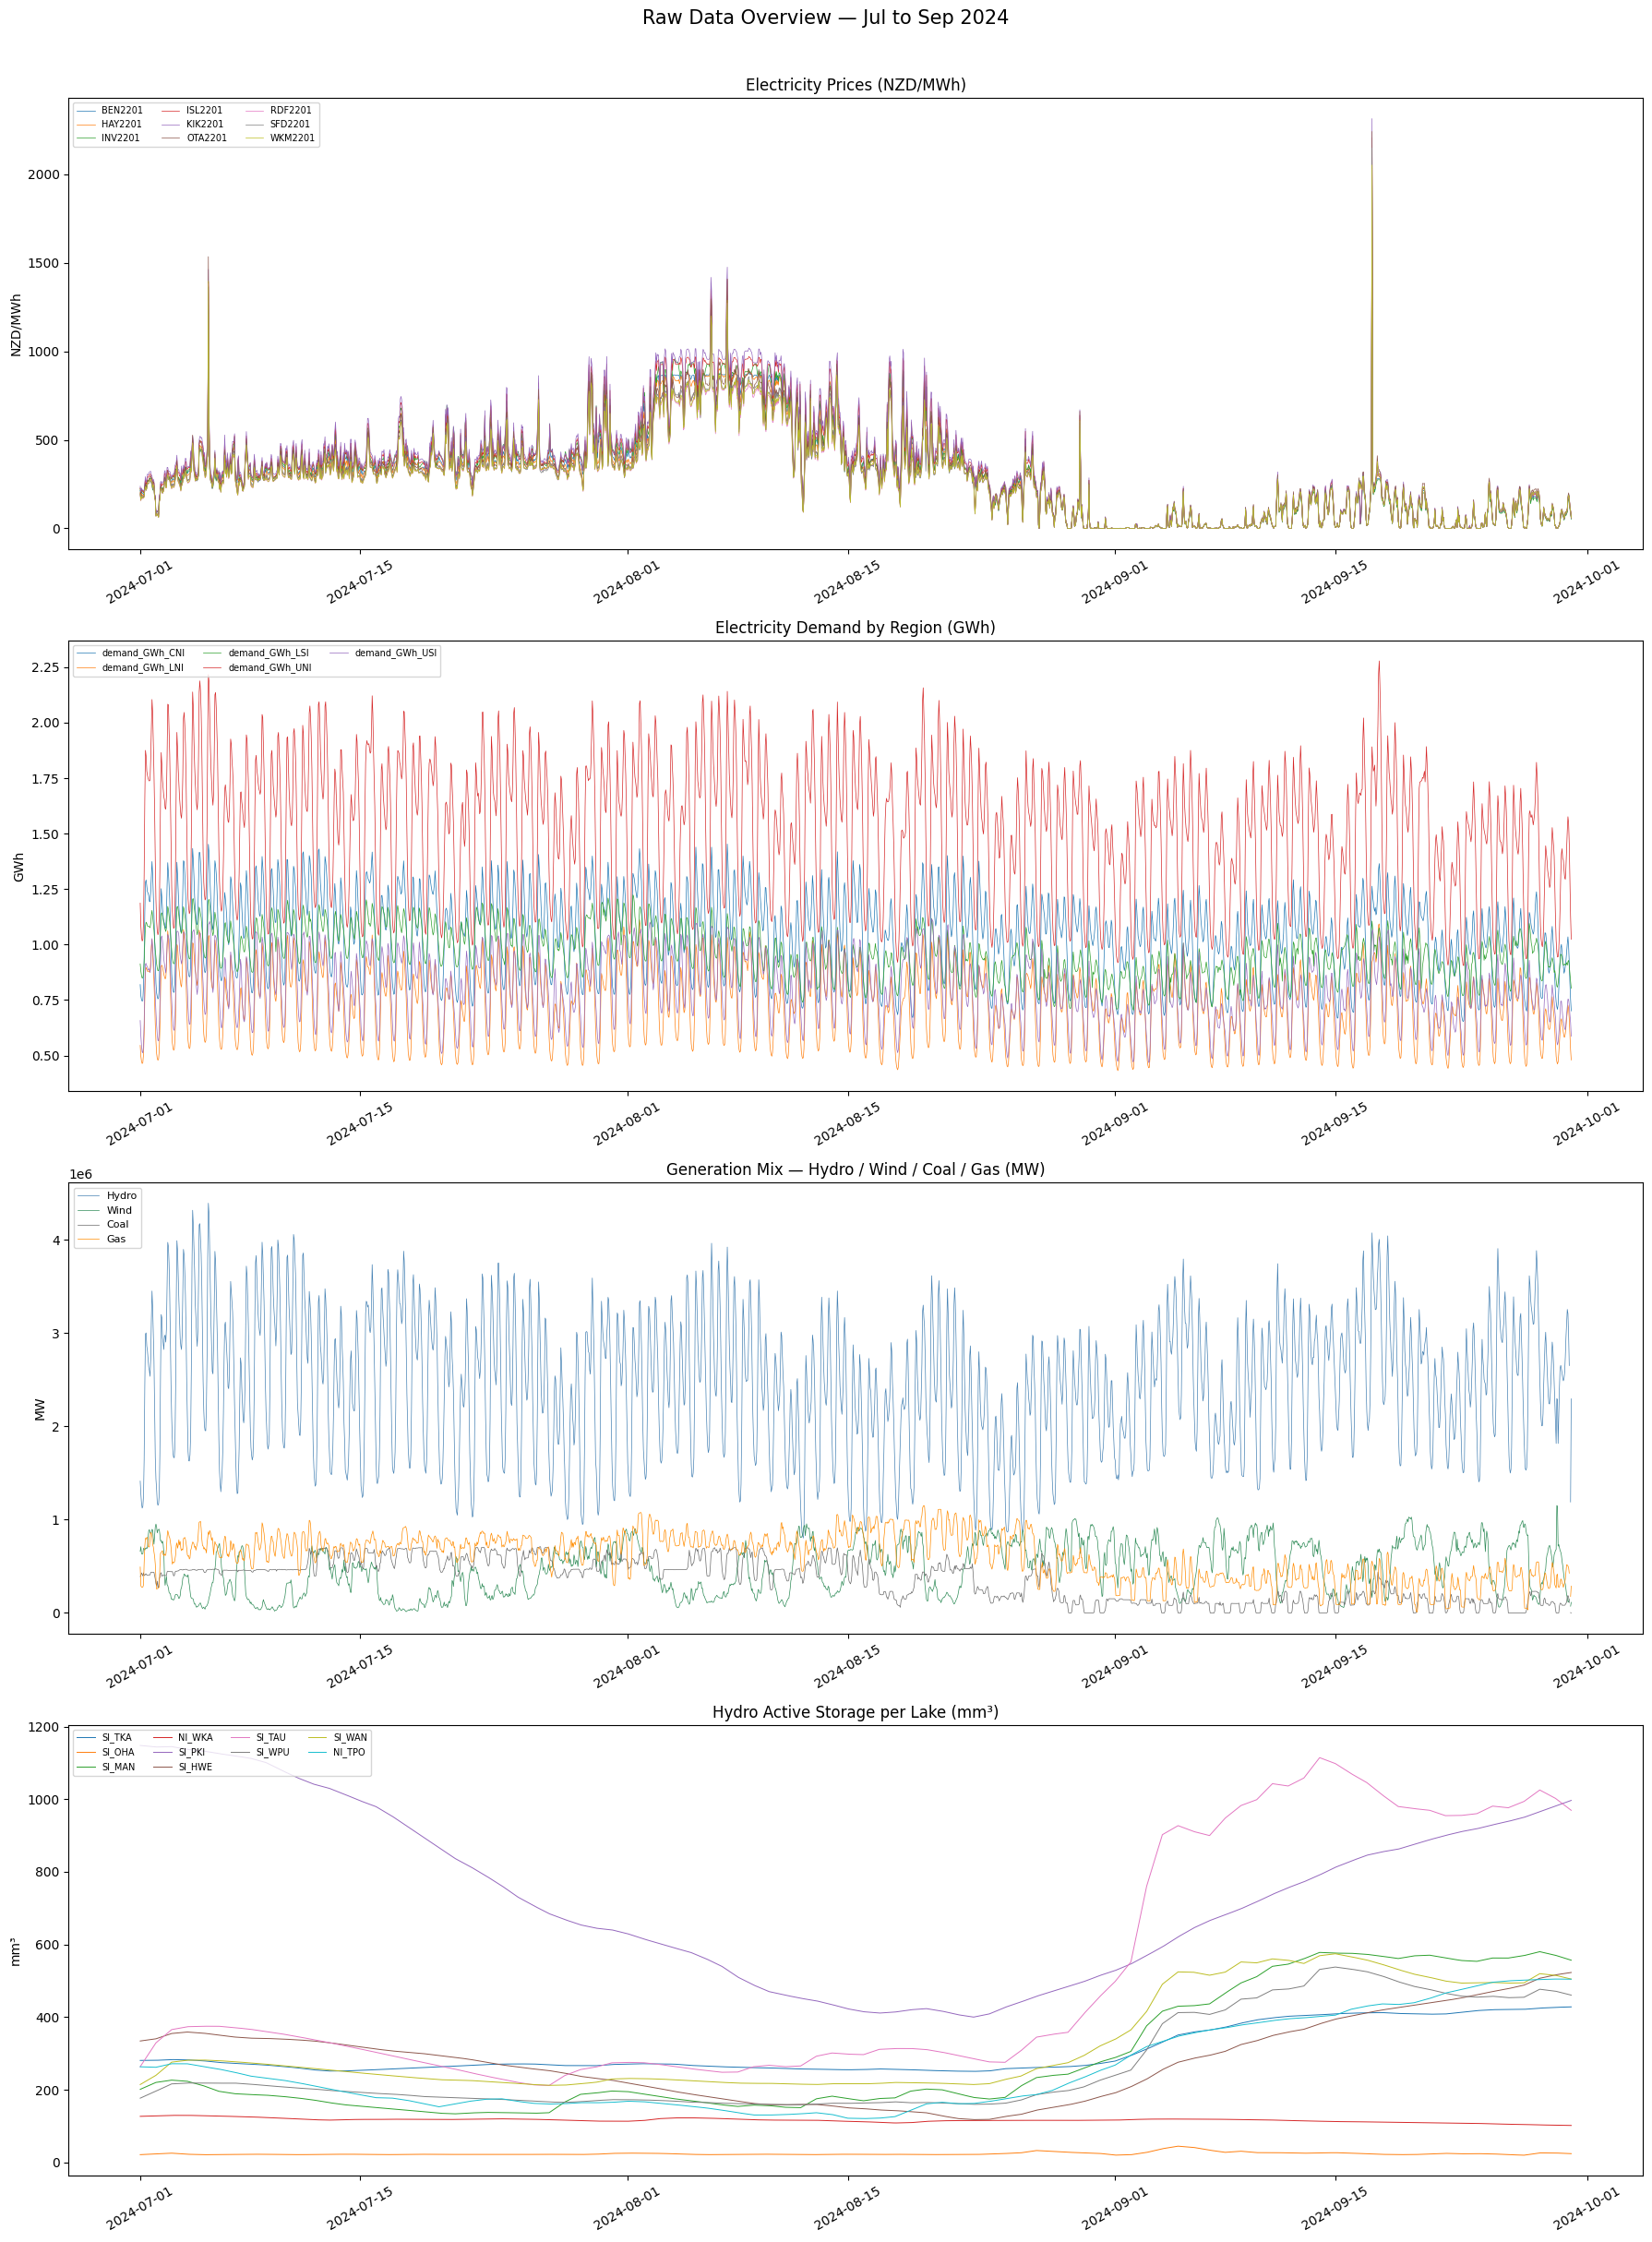

In [94]:
# EDA — Raw data overview Jul–Sep 2024

mask = (df["datetime_utc12"] >= "2024-07-01") & (df["datetime_utc12"] <= "2024-09-30")
df_plot = df[mask]

fig, axes = plt.subplots(4, 1, figsize=(18, 24))
fig.suptitle("Raw Data Overview — Jul to Sep 2024", fontsize=15, y=1.01)

price_cols = [c for c in df.columns if "el_price" in c]
ax = axes[0]
for col in price_cols:
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col.split("_")[-1])
ax.set_title("Electricity Prices (NZD/MWh)")
ax.set_ylabel("NZD/MWh")
ax.legend(fontsize=7, ncol=3, loc="upper left")

demand_cols = [c for c in df.columns if "demand_GWh" in c]
ax = axes[1]
for col in demand_cols:
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col)
ax.set_title("Electricity Demand by Region (GWh)")
ax.set_ylabel("GWh")
ax.legend(fontsize=7, ncol=3, loc="upper left")

gen_cols = ["Hydro", "Wind", "Coal", "Gas"]
colors   = ["steelblue", "seagreen", "dimgray", "darkorange"]
ax = axes[2]
for col, color in zip(gen_cols, colors):
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.5, label=col, color=color)
ax.set_title("Generation Mix — Hydro / Wind / Coal / Gas (MW)")
ax.set_ylabel("MW")
ax.legend(fontsize=8, loc="upper left")

storage_cols = [c for c in df.columns if "active_storage" in c]
ax = axes[3]
for col in storage_cols:
    ax.plot(df_plot["datetime_utc12"], df_plot[col], linewidth=0.7, label=col.split("__")[0])
ax.set_title("Hydro Active Storage per Lake (mm³)")
ax.set_ylabel("mm³")
ax.legend(fontsize=7, ncol=4, loc="upper left")

for ax in axes:
    ax.tick_params(axis="x", labelrotation=30)

plt.tight_layout()
plt.show()

In [95]:
# Forward-fill missing values
df = df.ffill()

In [96]:
# Lag non-target columns by 24h to prevent leakage
# Same as regressor — raw price is input, only y changes later

cols_to_shift_24h = [
    c for c in df.columns
    if "el_price" in c and c != target_col
] + [
    "Coal", "Diesel", "Ele", "Gas", "Geo", "Hydro", "Solar", "Wind", "Wood",
    "demand_GWh_CNI", "demand_GWh_LNI", "demand_GWh_LSI", "demand_GWh_UNI", "demand_GWh_USI",
    "avg_flow_MW", "peak_flow_MW", "Direction"
]

for col in cols_to_shift_24h:
    df[f"{col}_lag24"] = df[col].shift(24)
    df = df.drop(columns=[col])

In [97]:
print("Remaining dataframe shape:", df.shape)

price_cols_check = [c for c in df.columns if "el_price" in c and c != target_col]
print("Remaining other price columns:", price_cols_check)

Remaining dataframe shape: (52585, 81)
Remaining other price columns: ['el_price_dol_MWh_BEN2201_lag24', 'el_price_dol_MWh_HAY2201_lag24', 'el_price_dol_MWh_INV2201_lag24', 'el_price_dol_MWh_ISL2201_lag24', 'el_price_dol_MWh_KIK2201_lag24', 'el_price_dol_MWh_RDF2201_lag24', 'el_price_dol_MWh_SFD2201_lag24', 'el_price_dol_MWh_WKM2201_lag24']


In [98]:
# Cyclical time features

df["hour"]      = df["datetime_utc12"].dt.hour
df["dayofweek"] = df["datetime_utc12"].dt.dayofweek
df["month"]     = df["datetime_utc12"].dt.month
df["dayofyear"] = df["datetime_utc12"].dt.dayofyear
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

df["hour_sin"]  = np.sin(2 * np.pi * df["hour"]      / 24)
df["hour_cos"]  = np.cos(2 * np.pi * df["hour"]      / 24)
df["dow_sin"]   = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"]   = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"]     / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]     / 12)

print("Time features created successfully.")

Time features created successfully.


In [99]:
# Lag features built from raw price — these are INPUT features, not the target
# The classifier target y is defined later as spike class 0/1/2

df["target_lag_24h"]   = df[target_col].shift(24)
df["target_lag_168h"]  = df[target_col].shift(168)
df["target_lag_8760h"] = df[target_col].shift(8760)

print("Target lag features created.")
print(df[["target_lag_24h", "target_lag_168h", "target_lag_8760h"]].isna().sum())

Target lag features created.
target_lag_24h        24
target_lag_168h      168
target_lag_8760h    8760
dtype: int64


In [100]:
# Leakage-safe rolling window features — built from raw price

for window in [24, 168, 8760]:
    shifted = df[target_col].shift(1)
    df[f"rolling_mean_{window}h"] = shifted.rolling(window=window).mean()
    df[f"rolling_std_{window}h"]  = shifted.rolling(window=window).std()

print("Rolling features created.")
print(df[["rolling_mean_24h", "rolling_mean_168h", "rolling_mean_8760h"]].isna().sum())

Rolling features created.
rolling_mean_24h        24
rolling_mean_168h      168
rolling_mean_8760h    8760
dtype: int64


In [101]:
# NaN audit
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False).head(20))

target_lag_8760h                  8760
rolling_mean_8760h                8760
rolling_std_8760h                 8760
rolling_mean_168h                  168
rolling_std_168h                   168
target_lag_168h                    168
el_price_dol_MWh_HAY2201_lag24      24
el_price_dol_MWh_BEN2201_lag24      24
el_price_dol_MWh_INV2201_lag24      24
el_price_dol_MWh_ISL2201_lag24      24
Ele_lag24                           24
Gas_lag24                           24
el_price_dol_MWh_KIK2201_lag24      24
el_price_dol_MWh_RDF2201_lag24      24
el_price_dol_MWh_SFD2201_lag24      24
el_price_dol_MWh_WKM2201_lag24      24
Coal_lag24                          24
Diesel_lag24                        24
demand_GWh_CNI_lag24                24
Wood_lag24                          24
dtype: int64


In [102]:
# Drop warmup rows
rows_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Rows before: {rows_before}  |  After: {len(df)}  |  Removed: {rows_before - len(df)}")

Rows before: 52585  |  After: 43825  |  Removed: 8760


In [103]:
# Define feature matrix X
# NOTE: target_col (raw price) is excluded from X — it would be leakage.
# The lag/rolling features already capture past price information safely.

exclude_cols = ["datetime_utc12", target_col]

feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]

print("Feature matrix shape:", X.shape)
print("Number of features:", len(feature_cols))

Feature matrix shape: (43825, 99)
Number of features: 99


In [104]:
# Define spike labels using CENTERED rolling percentile thresholds
#
# Window looks 2 days BACK and 2 days FORWARD (96h total, center=True).
#
# Class labels:
#   0 = Normal       (price <= centered rolling 95th percentile)
#   1 = Weak spike   (95th < price <= 99th percentile)
#   2 = Strong spike (price > centered rolling 99th percentile)

split_ratio = 0.8
split_index = int(len(df) * split_ratio)

ROLLING_WINDOW  = 96    # 2 days back + 2 days forward
WEAK_QUANTILE   = 0.95  # top 5% → weak spike
STRONG_QUANTILE = 0.99  # top 1% → strong spike

weak_threshold_series   = df[target_col].rolling(ROLLING_WINDOW, center=True, min_periods=48).quantile(WEAK_QUANTILE)
strong_threshold_series = df[target_col].rolling(ROLLING_WINDOW, center=True, min_periods=48).quantile(STRONG_QUANTILE)

y = pd.Series(0, index=df.index, dtype=int)
y[df[target_col] > weak_threshold_series.fillna(float('inf'))]   = 1
y[df[target_col] > strong_threshold_series.fillna(float('inf'))] = 2

df["spike_threshold_weak"]   = weak_threshold_series.fillna(float('inf'))
df["spike_threshold_strong"] = strong_threshold_series.fillna(float('inf'))

print(f"Spike definition : centered rolling percentile  (window={ROLLING_WINDOW}h = ±2 days)")
print(f"  Weak spike     : price > centered rolling {int(WEAK_QUANTILE*100)}th percentile (top 5%)")
print(f"  Strong spike   : price > centered rolling {int(STRONG_QUANTILE*100)}th percentile (top 1%)")
print(f"\nClass distribution:")
counts = y.value_counts().sort_index()
for cls, label in zip([0,1,2], ["Normal", "Weak spike", "Strong spike"]):
    n = counts.get(cls, 0)
    print(f"  {label:15s}: {n:6d}  ({100*n/len(y):.1f}%)")

Spike definition : centered rolling percentile  (window=96h = ±2 days)
  Weak spike     : price > centered rolling 95th percentile (top 5%)
  Strong spike   : price > centered rolling 99th percentile (top 1%)

Class distribution:
  Normal         :  41832  (95.5%)
  Weak spike     :   1616  (3.7%)
  Strong spike   :    377  (0.9%)


Class distribution:
  0 — Normal            :  41832 hours  (95.5%)
  1 — Weak spike        :   1616 hours  (3.7%)
  2 — Strong spike      :    377 hours  (0.9%)


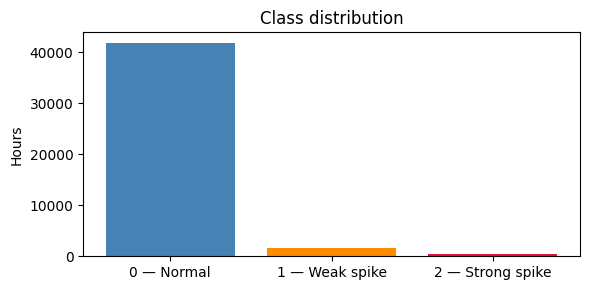

In [105]:
# Class distribution

counts = y.value_counts().sort_index()
labels = ["0 — Normal", "1 — Weak spike", "2 — Strong spike"]

print("Class distribution:")
for cls, label in zip([0, 1, 2], labels):
    n = counts.get(cls, 0)
    pct = 100 * n / len(y)
    print(f"  {label:22s}: {n:6d} hours  ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, [counts.get(c, 0) for c in [0, 1, 2]],
       color=["steelblue", "darkorange", "crimson"])
ax.set_title("Class distribution")
ax.set_ylabel("Hours")
plt.tight_layout()
plt.show()

In [106]:
# Time-based train/test split (80/20)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("\nTrain period:", df["datetime_utc12"].iloc[0], "to", df["datetime_utc12"].iloc[split_index - 1])
print("Test period: ", df["datetime_utc12"].iloc[split_index], "to", df["datetime_utc12"].iloc[-1])

Train shape: (35060, 99)
Test shape:  (8765, 99)

Train period: 2020-01-01 00:00:00 to 2023-12-31 19:00:00
Test period:  2023-12-31 20:00:00 to 2024-12-31 00:00:00


In [107]:
# Sample weights — inverse class frequency + recall bias
#
# Two layers of weighting:
#   1. compute_sample_weight('balanced') : corrects for class imbalance
#   2. SPIKE_WEIGHT_MULTIPLIER           : extra penalty for missing a spike
#                                          (missing a spike > false alarm)
#
# Increase SPIKE_WEIGHT_MULTIPLIER to make the model more aggressive at
# catching spikes (higher recall, lower precision).
# Start at 2.0 and tune up if too many spikes are missed.

SPIKE_WEIGHT_MULTIPLIER = 5.0  # tweak this

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Apply extra multiplier to spike classes (1 and 2)
spike_mask = y_train.values >= 1
sample_weights[spike_mask] *= SPIKE_WEIGHT_MULTIPLIER

# Sanity check
for cls in [0, 1, 2]:
    mask = y_train == cls
    print(f"Class {cls} — avg weight: {sample_weights[mask].mean():.2f}")

Class 0 — avg weight: 0.35
Class 1 — avg weight: 44.98
Class 2 — avg weight: 194.78


In [108]:
# Train XGBoost Classifier
#
# objective='multi:softmax' : multiclass classification
# num_class=3               : normal / weak spike / strong spike
# eval_metric='mlogloss'    : recommended for multiclass (replaces rmse)
# reg_alpha=1.0             : L1 regularization (same as regressor)

xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train, sample_weight=sample_weights)

print("XGBoost classifier trained successfully.")

XGBoost classifier trained successfully.


In [109]:
# Predict using probability threshold — recall-biased spike detection
#
# Instead of predict() which always picks the highest-probability class,
# we use predict_proba() and flag an hour as a spike if the combined
# probability of being a spike (class 1 or 2) exceeds SPIKE_PROB_THRESHOLD.
#
# Lower SPIKE_PROB_THRESHOLD = more spikes flagged = higher recall, lower precision
# Higher SPIKE_PROB_THRESHOLD = fewer spikes flagged = lower recall, higher precision
#
# Default predict() behaviour = threshold of 0.5 on the winning class.
# We set it lower here because missing a spike is worse than a false alarm.

SPIKE_PROB_THRESHOLD = 0.2  # tweak this (try 0.2 – 0.5)

def predict_with_threshold(model, X, threshold=SPIKE_PROB_THRESHOLD):
    proba = model.predict_proba(X)          # shape: (n, 3)
    prob_spike = proba[:, 1] + proba[:, 2]  # combined P(weak) + P(strong)

    # Start with default (argmax) prediction
    pred = np.argmax(proba, axis=1)

    # Override: if combined spike probability exceeds threshold, flag as spike
    # Pick the stronger spike class if both are plausible
    is_spike = prob_spike >= threshold
    pred[is_spike] = np.where(proba[is_spike, 2] >= proba[is_spike, 1], 2, 1)

    return pred

y_pred = predict_with_threshold(xgb_clf, X_test)

print(f"Spike probability threshold : {SPIKE_PROB_THRESHOLD}")
print("Predicted class counts:", dict(zip(*np.unique(y_pred, return_counts=True))))

Spike probability threshold : 0.2
Predicted class counts: {0: 5757, 1: 2940, 2: 68}


              precision    recall  f1-score   support

      Normal       0.99      0.68      0.80      8371
  Weak spike       0.08      0.74      0.14       317
Strong spike       0.06      0.05      0.06        77

    accuracy                           0.67      8765
   macro avg       0.38      0.49      0.33      8765
weighted avg       0.95      0.67      0.77      8765



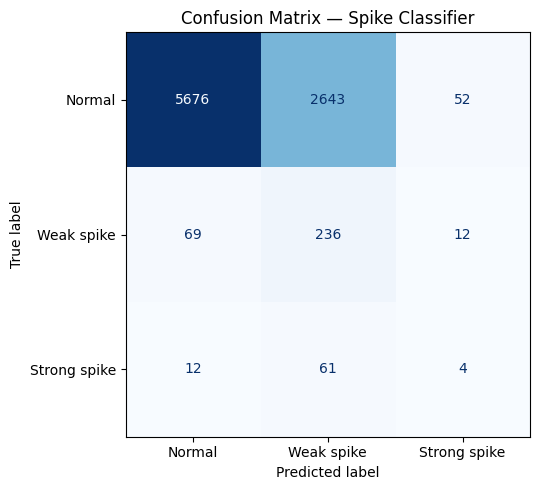

In [110]:
# Evaluate — classification metrics
#
# Focus on the spike classes (1 and 2):
#   Precision : of predicted spikes, how many were real?
#   Recall    : of real spikes, how many did we catch?
#   F1        : harmonic mean of precision and recall

print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Weak spike", "Strong spike"]
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Weak spike", "Strong spike"]
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Spike Classifier")
plt.tight_layout()
plt.show()

In [111]:
# Feature importance

importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": xgb_clf.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(20).to_string(index=False))

                       feature  importance
                          hour    0.028646
               Direction_lag24    0.023041
                     month_cos    0.017673
el_price_dol_MWh_WKM2201_lag24    0.014982
         dunedin_shortwave_wm2    0.014101
        hamilton_shortwave_wm2    0.013670
        auckland_shortwave_wm2    0.013631
          demand_GWh_CNI_lag24    0.013486
        tauranga_shortwave_wm2    0.013457
          demand_GWh_LSI_lag24    0.012814
    christchurch_shortwave_wm2    0.012790
      wellington_shortwave_wm2    0.012312
    SI_WPU__active_storage_mm³    0.012306
                target_lag_24h    0.012177
    SI_MAN__active_storage_mm³    0.012165
                      hour_cos    0.012085
el_price_dol_MWh_SFD2201_lag24    0.012052
          demand_GWh_LNI_lag24    0.011988
el_price_dol_MWh_INV2201_lag24    0.011624
                    is_weekend    0.011337


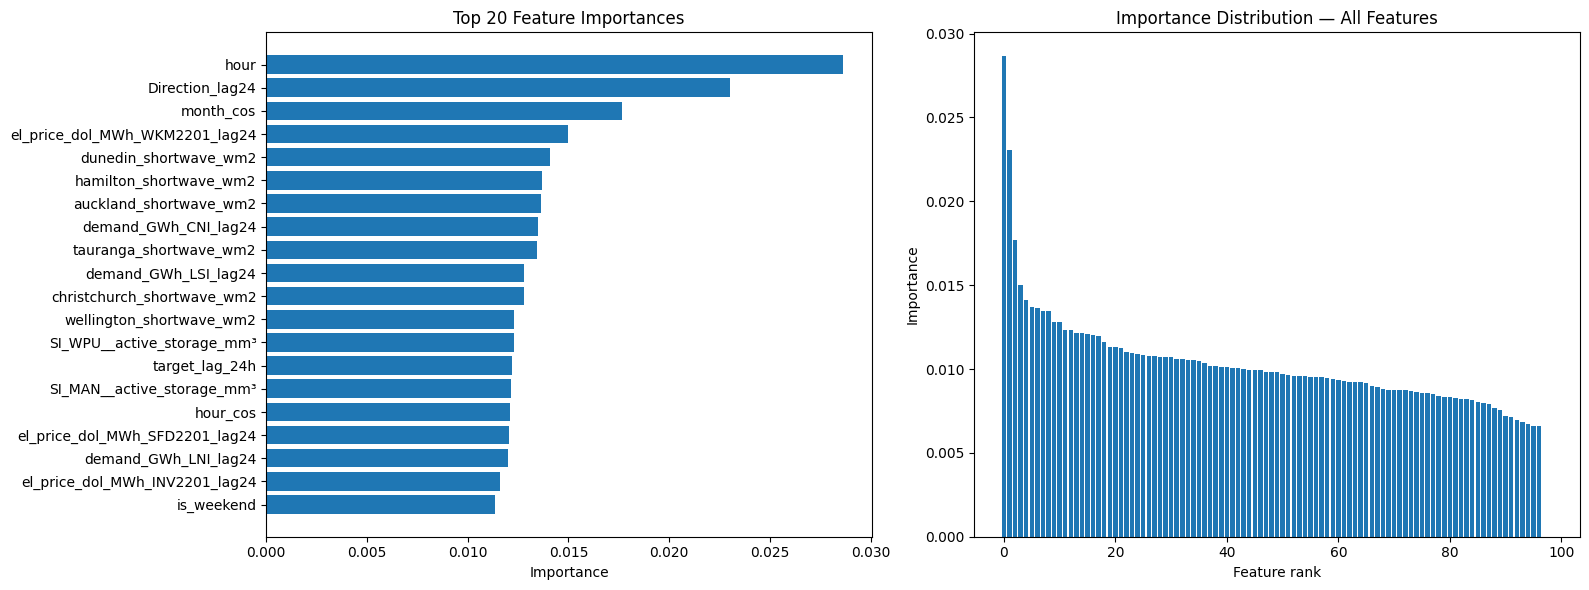

In [112]:
# Feature importance plots

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 bar chart
top20 = importance_df.head(20)
axes[0].barh(top20["feature"][::-1], top20["importance"][::-1])
axes[0].set_title("Top 20 Feature Importances")
axes[0].set_xlabel("Importance")

# Full distribution
axes[1].bar(range(len(importance_df)), importance_df["importance"].values)
axes[1].set_title("Importance Distribution — All Features")
axes[1].set_xlabel("Feature rank")
axes[1].set_ylabel("Importance")

plt.tight_layout()
plt.show()

In [113]:
# Pruned classifier — drop features below importance threshold

IMPORTANCE_THRESHOLD = 0.005

above_threshold = importance_df[importance_df["importance"] >= IMPORTANCE_THRESHOLD]
below_threshold = importance_df[importance_df["importance"] <  IMPORTANCE_THRESHOLD]
selected_features = above_threshold["feature"].tolist()

print(f"Threshold : {IMPORTANCE_THRESHOLD}")
print(f"Retained  : {len(selected_features)}  |  Dropped: {len(below_threshold)}")
print("\nDropped features:")
for f in below_threshold["feature"].tolist():
    print(f"  - {f}")

X_train_pruned = X_train[selected_features]
X_test_pruned  = X_test[selected_features]

xgb_clf_pruned = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_clf_pruned.fit(X_train_pruned, y_train, sample_weight=sample_weights)
y_pred_pruned = xgb_clf_pruned.predict(X_test_pruned)

print("\n--- Pruned model ---")
print(classification_report(
    y_test, y_pred_pruned,
    target_names=["Normal", "Weak spike", "Strong spike"]
))

Threshold : 0.005
Retained  : 97  |  Dropped: 2

Dropped features:
  - Solar_lag24
  - Ele_lag24

--- Pruned model ---
              precision    recall  f1-score   support

      Normal       0.97      0.88      0.92      8371
  Weak spike       0.11      0.39      0.17       317
Strong spike       0.05      0.03      0.03        77

    accuracy                           0.85      8765
   macro avg       0.38      0.43      0.38      8765
weighted avg       0.93      0.85      0.89      8765



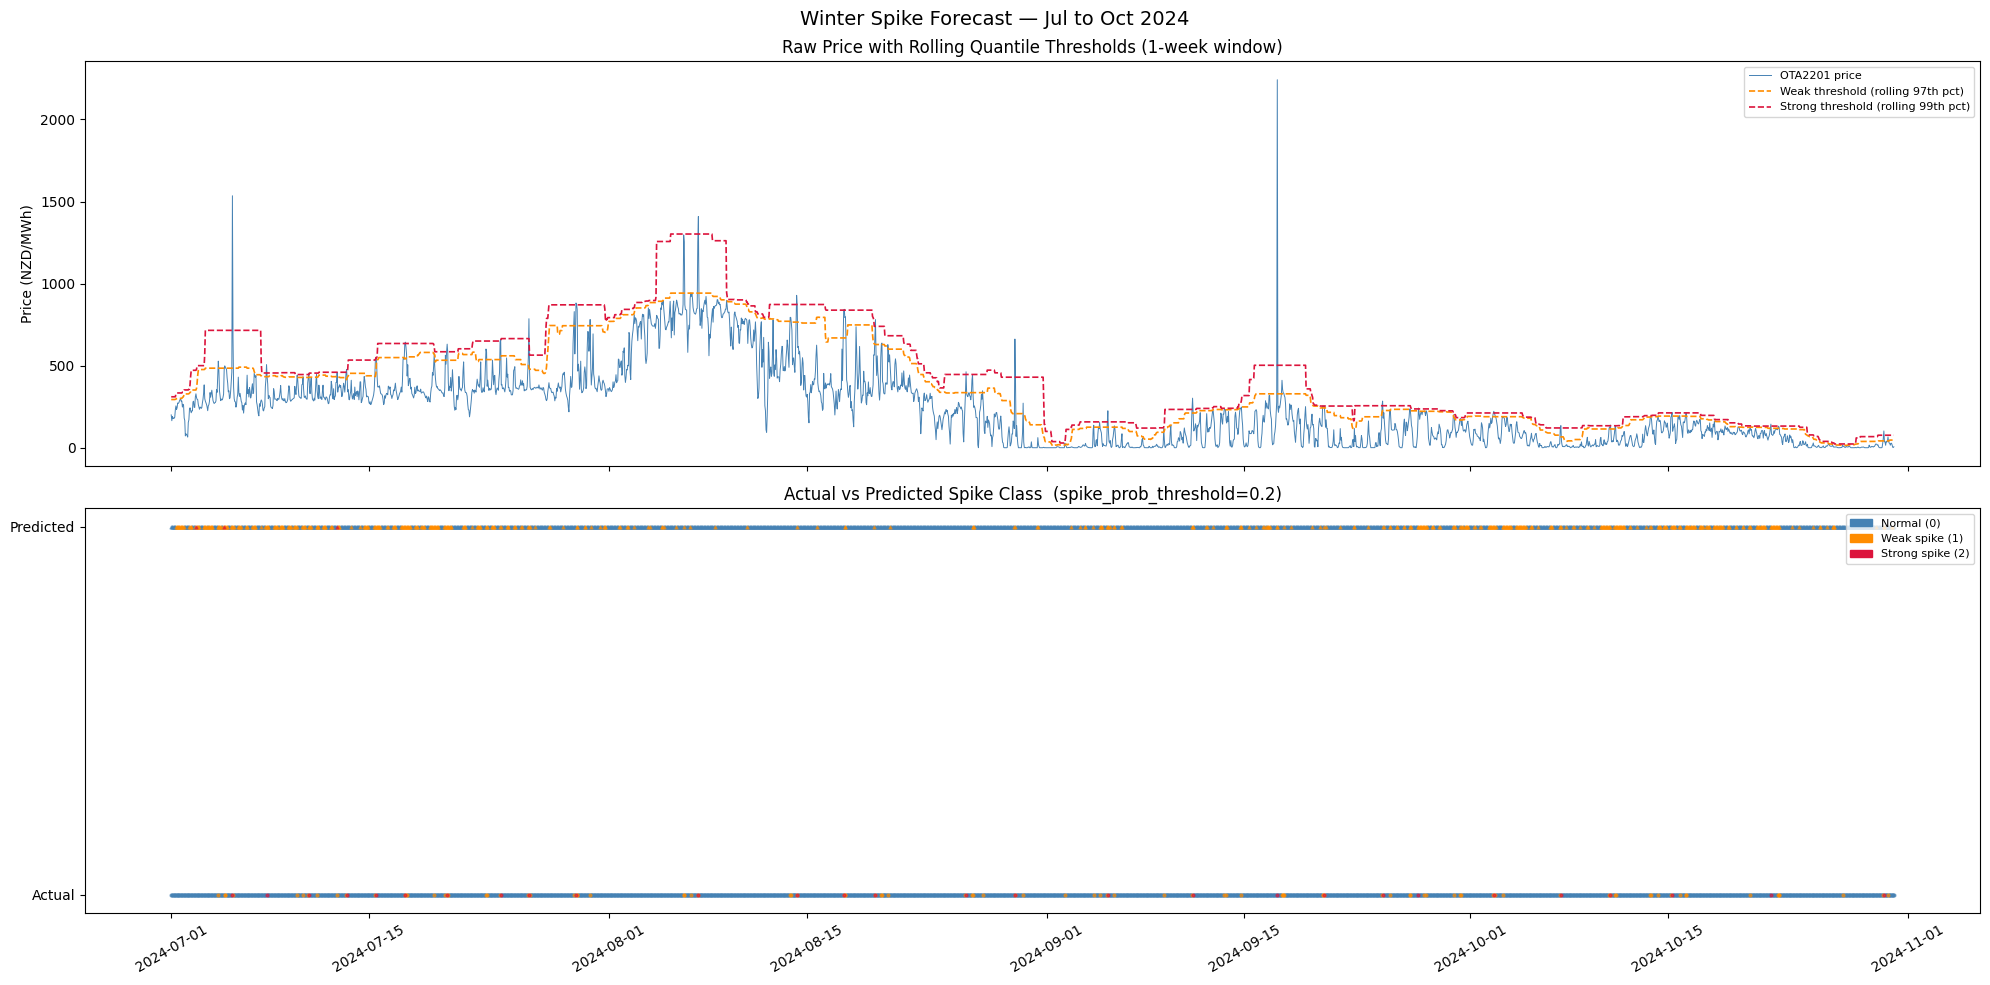


Winter window classification report:
              precision    recall  f1-score   support

      Normal       0.98      0.82      0.89      2805
  Weak spike       0.10      0.60      0.17        96
Strong spike       0.00      0.00      0.00        28

    accuracy                           0.80      2929
   macro avg       0.36      0.47      0.35      2929
weighted avg       0.94      0.80      0.86      2929



In [114]:
# 4-month winter rolling forecast — Jul 1 to Oct 31 2024

winter_mask = (
    (df["datetime_utc12"] >= "2024-07-01") &
    (df["datetime_utc12"] <= "2024-10-31")
)

df_winter  = df[winter_mask].reset_index(drop=True)
X_winter   = df_winter[feature_cols]
timestamps = df_winter["datetime_utc12"].values
raw_price  = df_winter[target_col].values
weak_line   = df_winter["spike_threshold_weak"].values
strong_line = df_winter["spike_threshold_strong"].values

y_actual_cls = np.zeros(len(df_winter), dtype=int)
y_actual_cls[raw_price > weak_line]   = 1
y_actual_cls[raw_price > strong_line] = 2

y_pred_cls = predict_with_threshold(xgb_clf, X_winter)

colors_map = {0: "steelblue", 1: "darkorange", 2: "crimson"}

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
fig.suptitle("Winter Spike Forecast — Jul to Oct 2024", fontsize=14)

ax1 = axes[0]
ax1.plot(timestamps, raw_price,  color="steelblue",  linewidth=0.7, label="OTA2201 price")
ax1.plot(timestamps, weak_line,  color="darkorange",  linewidth=1.2, linestyle="--",
         label=f"Weak threshold (rolling 97th pct)")
ax1.plot(timestamps, strong_line, color="crimson",   linewidth=1.2, linestyle="--",
         label=f"Strong threshold (rolling 99th pct)")
ax1.set_ylabel("Price (NZD/MWh)")
ax1.legend(fontsize=8, loc="upper right")
ax1.set_title("Raw Price with Rolling Quantile Thresholds (1-week window)")

ax2 = axes[1]
for cls in [0, 1, 2]:
    mask_cls = y_actual_cls == cls
    ax2.scatter(timestamps[mask_cls], np.full(mask_cls.sum(), 0.2),
                c=colors_map[cls], s=4, alpha=0.6)
for cls in [0, 1, 2]:
    mask_cls = y_pred_cls == cls
    ax2.scatter(timestamps[mask_cls], np.full(mask_cls.sum(), 0.8),
                c=colors_map[cls], s=4, alpha=0.6, marker="^")

ax2.set_yticks([0.2, 0.8])
ax2.set_yticklabels(["Actual", "Predicted"])
ax2.set_title(f"Actual vs Predicted Spike Class  (spike_prob_threshold={SPIKE_PROB_THRESHOLD})")
ax2.tick_params(axis="x", labelrotation=30)

patches = [
    mpatches.Patch(color="steelblue",  label="Normal (0)"),
    mpatches.Patch(color="darkorange", label="Weak spike (1)"),
    mpatches.Patch(color="crimson",    label="Strong spike (2)"),
]
ax2.legend(handles=patches, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

print("\nWinter window classification report:")
print(classification_report(
    y_actual_cls, y_pred_cls,
    target_names=["Normal", "Weak spike", "Strong spike"]
))

In [115]:
# -------------------------------------------------------
# Helper: spike forecast plot + window extractor
# -------------------------------------------------------

def plot_spike_forecast(ax, timestamps, price,
                        y_actual, y_pred,
                        roll_weak, roll_strong,
                        title=""):
    colors_map = {0: "steelblue", 1: "darkorange", 2: "crimson"}
    labels_map = {0: "Predicted: Normal",
                  1: "Predicted: Weak spike",
                  2: "Predicted: Strong spike"}

    for cls in [0, 1, 2]:
        mask = y_pred == cls
        ax.scatter(timestamps[mask], price[mask],
                   c=colors_map[cls], s=3, zorder=2,
                   label=labels_map[cls])

    ax.plot(timestamps, roll_weak,   color="darkorange", linewidth=0.8,
            linestyle="--", alpha=0.6, zorder=1, label="Weak threshold (97th pct)")
    ax.plot(timestamps, roll_strong, color="crimson",    linewidth=0.8,
            linestyle="--", alpha=0.6, zorder=1, label="Strong threshold (99th pct)")

    y_offset = price.max() * 0.05
    for cls, color, marker in [(1, "darkorange", "^"), (2, "crimson", "D")]:
        mask = y_actual == cls
        if mask.any():
            ax.scatter(timestamps[mask], price[mask] + y_offset,
                       c=color, marker=marker, s=20, zorder=3,
                       edgecolors="black", linewidths=0.3,
                       label=f"Actual {'weak' if cls==1 else 'strong'} spike")

    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Price (NZD/MWh)")
    ax.tick_params(axis="x", labelrotation=30)


def get_window(start_date, end_date):
    mask = (
        (df["datetime_utc12"] >= pd.Timestamp(start_date)) &
        (df["datetime_utc12"] <  pd.Timestamp(end_date))
    )
    d = df[mask].reset_index(drop=True)
    timestamps  = d["datetime_utc12"].values
    price       = d[target_col].values
    roll_weak   = d["spike_threshold_weak"].values    # rolling 97th pct
    roll_strong = d["spike_threshold_strong"].values  # rolling 99th pct

    y_actual = np.zeros(len(d), dtype=int)
    y_actual[price > roll_weak]   = 1
    y_actual[price > roll_strong] = 2

    y_pred = predict_with_threshold(xgb_clf, d[feature_cols])

    return timestamps, price, y_actual, y_pred, roll_weak, roll_strong


print("plot_spike_forecast() and get_window() defined.")

plot_spike_forecast() and get_window() defined.


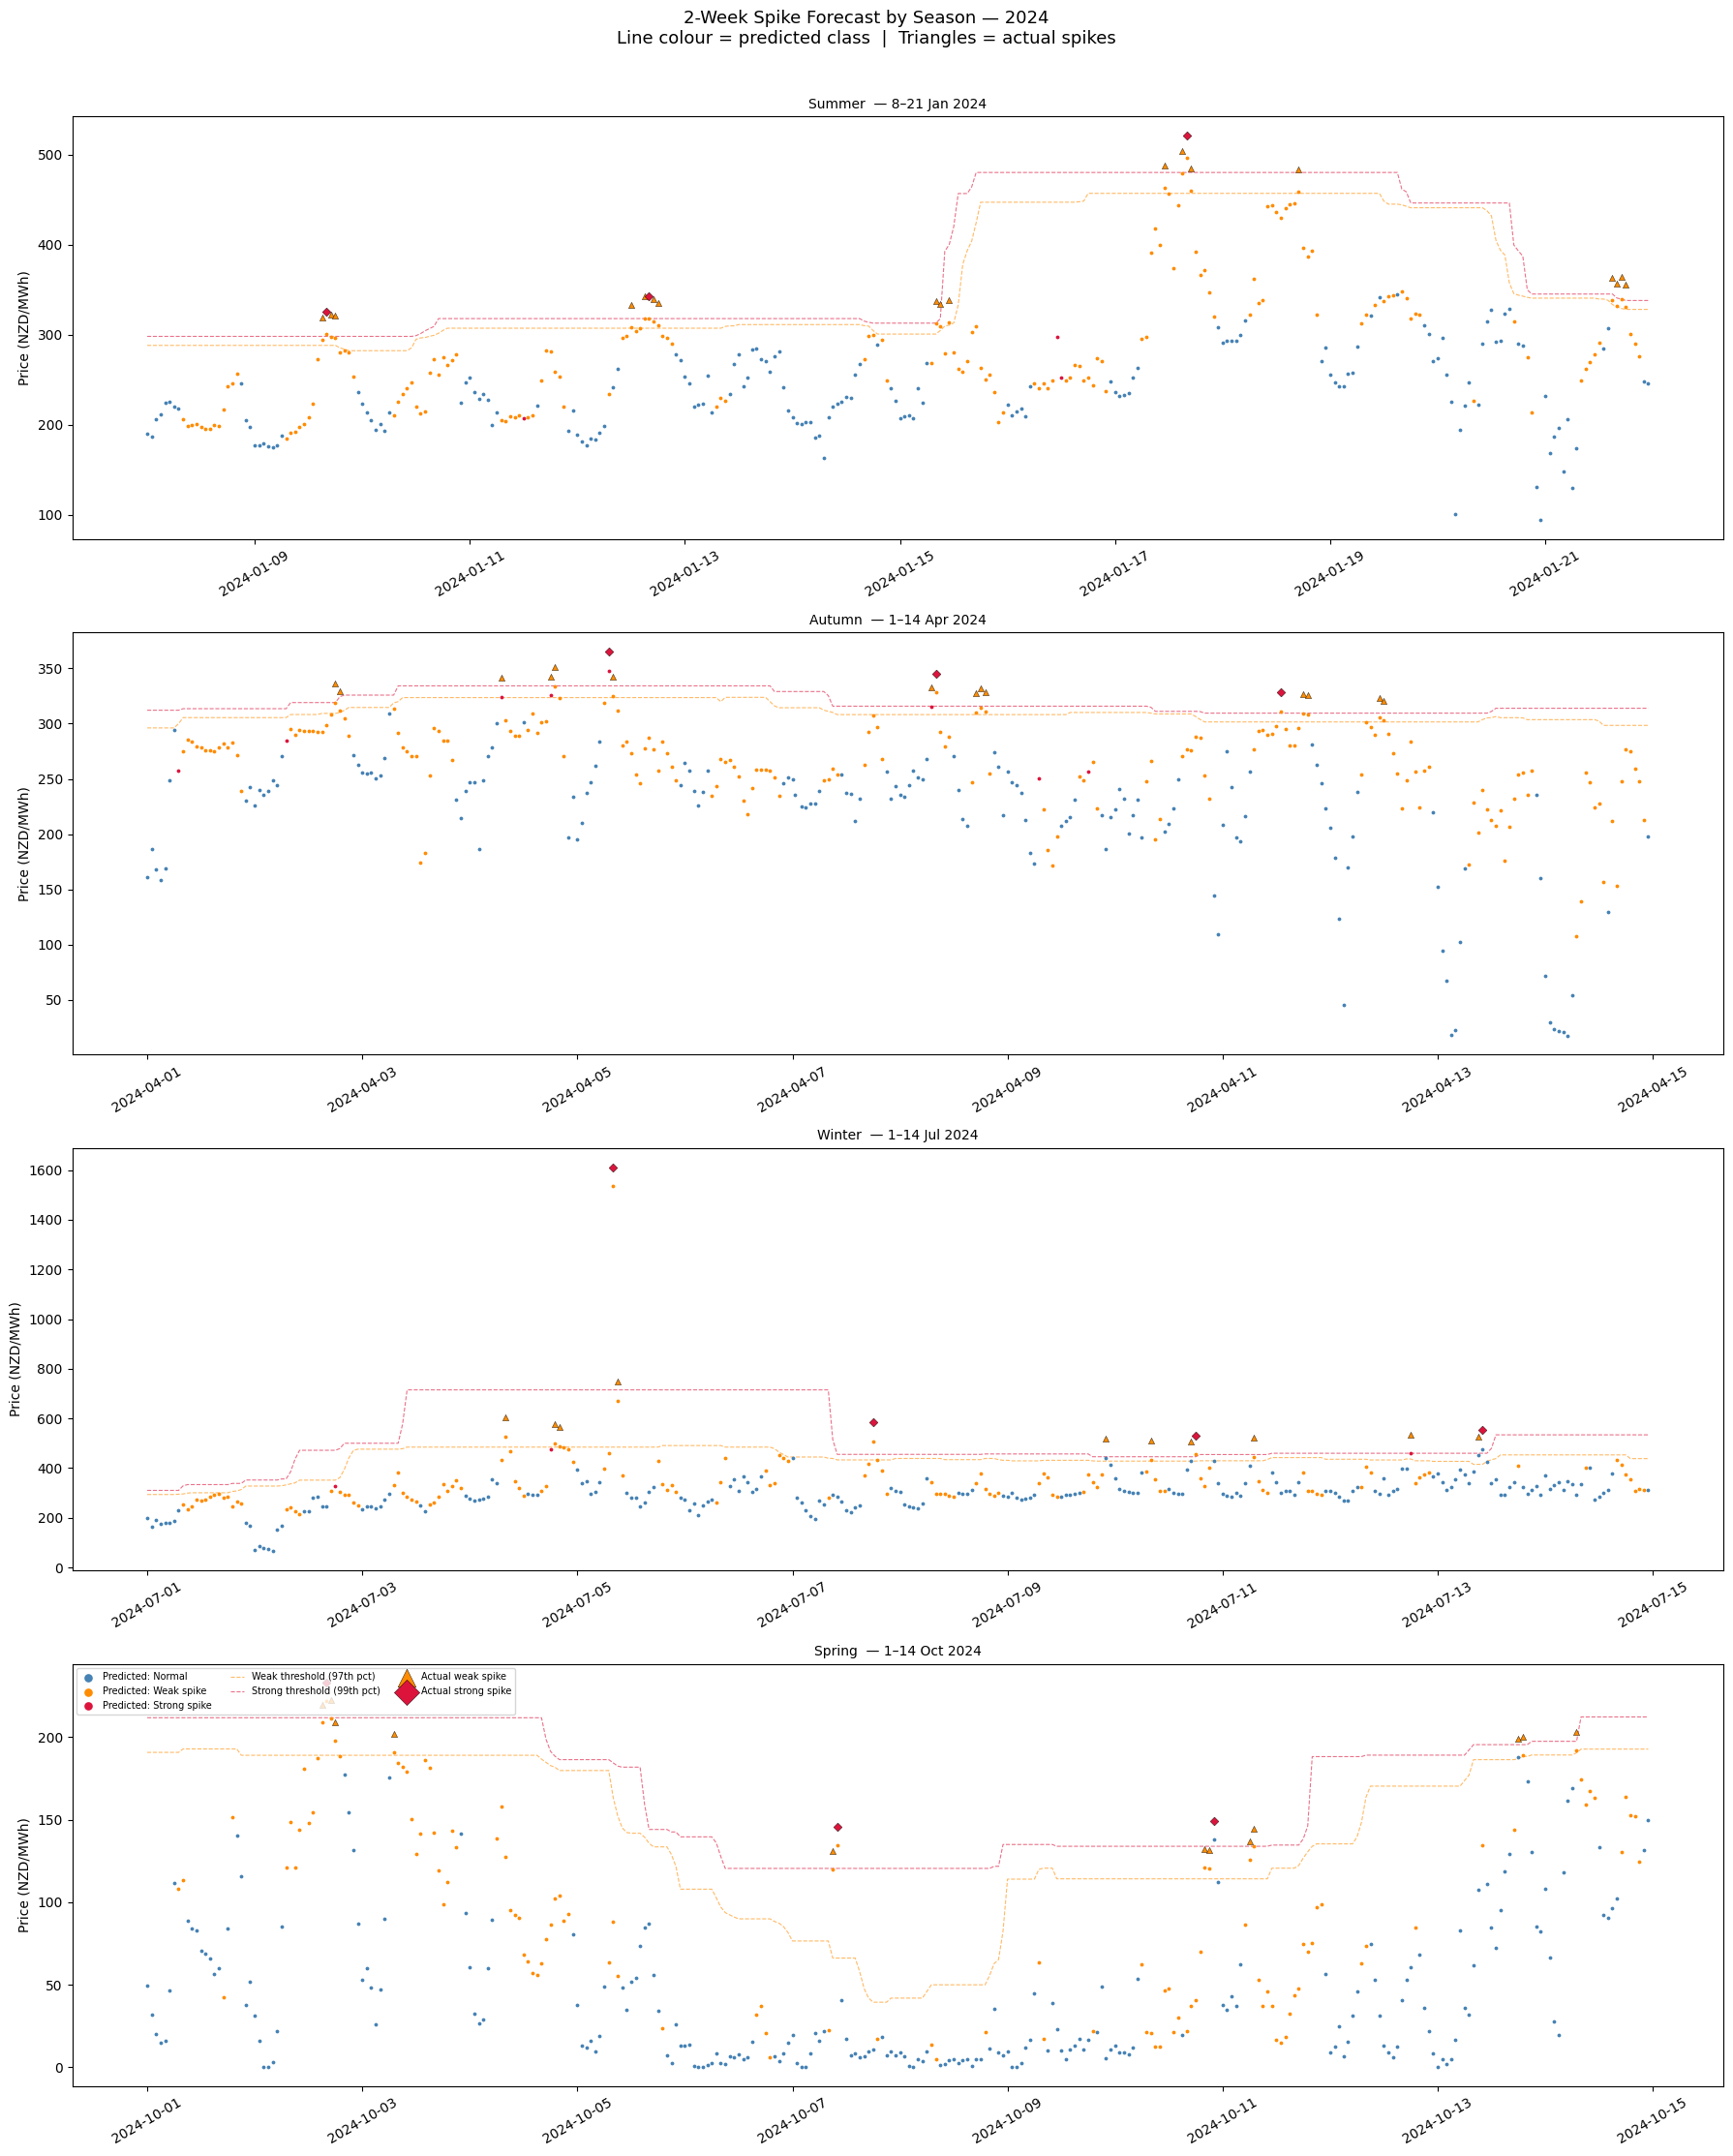

In [116]:
# -------------------------------------------------------
# Seasonal 2-week spike forecasts — 2024 (NZ seasons)
# -------------------------------------------------------
# Summer : Jan  |  Autumn : Apr  |  Winter : Jul  |  Spring : Oct

seasons = {
    "Summer  — 8–21 Jan 2024":  ("2024-01-08", "2024-01-22"),
    "Autumn  — 1–14 Apr 2024":  ("2024-04-01", "2024-04-15"),
    "Winter  — 1–14 Jul 2024":  ("2024-07-01", "2024-07-15"),
    "Spring  — 1–14 Oct 2024":  ("2024-10-01", "2024-10-15"),
}

fig, axes = plt.subplots(4, 1, figsize=(18, 22))
fig.suptitle("2-Week Spike Forecast by Season — 2024\n"
             "Line colour = predicted class  |  Triangles = actual spikes",
             fontsize=13, y=1.01)

for ax, (label, (start, end)) in zip(axes, seasons.items()):
    ts, price, y_act, y_pred, rw, rs = get_window(start, end)
    plot_spike_forecast(ax, ts, price, y_act, y_pred, rw, rs, title=label)

# Single shared legend on the last axis
axes[-1].legend(fontsize=7, ncol=3, loc="upper left",
                markerscale=3, handlelength=1.5)

plt.tight_layout()
plt.show()

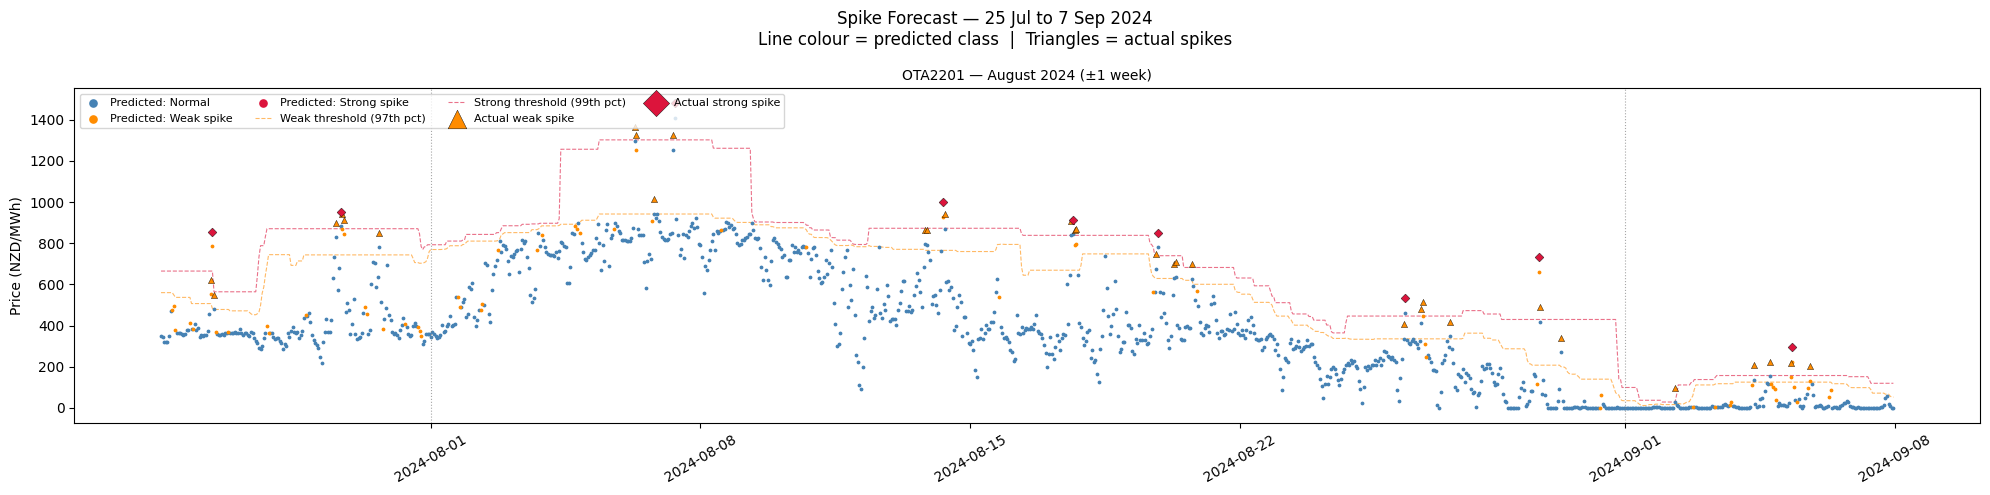

Window: 25 Jul – 7 Sep 2024  (1080 hours)
Actual  spikes — weak: 31  strong: 9
Predicted spikes — weak: 66  strong: 0


In [117]:
# -------------------------------------------------------
# August 2024 — extended window (25 Jul to 7 Sep)
# -------------------------------------------------------
# A few days either side of August for context.

ts, price, y_act, y_pred, rw, rs = get_window("2024-07-25", "2024-09-08")

fig, ax = plt.subplots(figsize=(20, 5))
fig.suptitle("Spike Forecast — 25 Jul to 7 Sep 2024\n"
             "Line colour = predicted class  |  Triangles = actual spikes",
             fontsize=12)

plot_spike_forecast(ax, ts, price, y_act, y_pred, rw, rs,
                    title="OTA2201 — August 2024 (±1 week)")

ax.legend(fontsize=8, ncol=4, loc="upper left", markerscale=3, handlelength=1.5)
ax.axvline(pd.Timestamp("2024-08-01"), color="gray", linewidth=0.8,
           linestyle=":", alpha=0.7, label="Aug 1")
ax.axvline(pd.Timestamp("2024-09-01"), color="gray", linewidth=0.8,
           linestyle=":", alpha=0.7, label="Sep 1")

plt.tight_layout()
plt.show()

# Quick stats for this window
print(f"Window: 25 Jul – 7 Sep 2024  ({len(ts)} hours)")
print(f"Actual  spikes — weak: {(y_act==1).sum()}  strong: {(y_act==2).sum()}")
print(f"Predicted spikes — weak: {(y_pred==1).sum()}  strong: {(y_pred==2).sum()}")